In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kaiwalyaatulraut/construction-and-electrical-boq-dataset/boq_projects.csv
/kaggle/input/datasets/kaiwalyaatulraut/construction-and-electrical-boq-dataset/boq_line_items.csv
/kaggle/input/datasets/kaiwalyaatulraut/construction-and-electrical-boq-dataset/data_dictionary_line_items.csv
/kaggle/input/datasets/kaiwalyaatulraut/construction-and-electrical-boq-dataset/data_dictionary_projects.csv


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report
)

import lightgbm as lgb

import shap
import joblib
import os

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
projects = pd.read_csv(
    "/kaggle/input/datasets/kaiwalyaatulraut/construction-and-electrical-boq-dataset/boq_projects.csv"
)

items = pd.read_csv(
    "/kaggle/input/datasets/kaiwalyaatulraut/construction-and-electrical-boq-dataset/boq_line_items.csv"
)

print(projects.shape)
print(items.shape)

projects.head()

(800, 13)
(25644, 9)


,project_id,building_type,city,state,built_up_area_sqft,num_floors,project_start_date,estimated_duration_months,total_civil_cost_inr,total_electrical_cost_inr,total_plumbing_cost_inr,total_project_cost_inr,cost_per_sqft_inr
0,PRJ0001,Commercial - Hotel,Jaipur,Rajasthan,86553.0,4,2024-04-24,16.0,3.123988e+08,7412338.92,4631561.83,3.244427e+08,3748.49
1,PRJ0002,Industrial - Heavy Manufacturing,Surat,Gujarat,52963.0,3,2023-12-29,13.0,3.504336e+08,7396210.28,2285286.11,3.601150e+08,6799.37
2,PRJ0003,Residential - Independent House,Ahmedabad,Gujarat,1829.0,4,2025-12-17,11.0,7.078587e+06,1805663.67,180915.27,9.065166e+06,4956.35
3,PRJ0004,Commercial - Hospital,Surat,Gujarat,280394.0,5,2021-10-18,11.0,7.384973e+08,18694471.64,33106411.74,7.902981e+08,2818.53
4,PRJ0005,Industrial - Warehouse,Jaipur,Rajasthan,171320.0,11,2023-08-03,14.0,6.835707e+08,17620358.94,18474715.90,7.196658e+08,4200.71


In [4]:
projects.columns

Index(['project_id', 'building_type', 'city', 'state', 'built_up_area_sqft',
       'num_floors', 'project_start_date', 'estimated_duration_months',
       'total_civil_cost_inr', 'total_electrical_cost_inr',
       'total_plumbing_cost_inr', 'total_project_cost_inr',
       'cost_per_sqft_inr'],
      dtype='object')

In [5]:
items.columns

Index(['item_id', 'project_id', 'category', 'sub_category', 'item_name',
       'unit', 'quantity', 'rate_per_unit_inr', 'amount_inr'],
      dtype='object')

In [6]:

df = items.merge(
    projects,
    on="project_id",
    how="left"
)

print("="*60)
print("Merged Dataset Shape")
print(df.shape)

print("\nFirst 5 Rows")
display(df.head())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Merged Dataset Shape
(25644, 21)

First 5 Rows


,item_id,project_id,category,sub_category,item_name,unit,quantity,rate_per_unit_inr,amount_inr,building_type,...,state,built_up_area_sqft,num_floors,project_start_date,estimated_duration_months,total_civil_cost_inr,total_electrical_cost_inr,total_plumbing_cost_inr,total_project_cost_inr,cost_per_sqft_inr
0,ITM000001,PRJ0001,Civil,Concrete,RCC M25 for footings/columns,cum,1936.67,8063.14,15615641.34,Commercial - Hotel,...,Rajasthan,86553.0,4,2024-04-24,16.0,3.123988e+08,7412338.92,4631561.83,3.244427e+08,3748.49
1,ITM000002,PRJ0001,Civil,Earthwork,Backfilling with excavated earth,cum,1476.05,125.48,185214.75,Commercial - Hotel,...,Rajasthan,86553.0,4,2024-04-24,16.0,3.123988e+08,7412338.92,4631561.83,3.244427e+08,3748.49
2,ITM000003,PRJ0001,Civil,Roofing,RCC roof slab with waterproofing,sqm,73651.01,1163.75,85711362.89,Commercial - Hotel,...,Rajasthan,86553.0,4,2024-04-24,16.0,3.123988e+08,7412338.92,4631561.83,3.244427e+08,3748.49
3,ITM000004,PRJ0001,Civil,Reinforcement,TMT steel bars Fe 500,kg,415703.01,67.25,27956027.42,Commercial - Hotel,...,Rajasthan,86553.0,4,2024-04-24,16.0,3.123988e+08,7412338.92,4631561.83,3.244427e+08,3748.49
4,ITM000005,PRJ0001,Civil,Masonry,Brickwork in CM 1:6 (230mm),sqm,41611.05,668.92,27834463.57,Commercial - Hotel,...,Rajasthan,86553.0,4,2024-04-24,16.0,3.123988e+08,7412338.92,4631561.83,3.244427e+08,3748.49



Missing Values
item_id                        0
project_id                     0
category                       0
sub_category                   0
item_name                      0
unit                           0
quantity                       0
rate_per_unit_inr            391
amount_inr                   391
building_type                  0
city                           0
state                          0
built_up_area_sqft             0
num_floors                     0
project_start_date             0
estimated_duration_months    517
total_civil_cost_inr           0
total_electrical_cost_inr      0
total_plumbing_cost_inr        0
total_project_cost_inr         0
cost_per_sqft_inr              0
dtype: int64

Duplicate Rows
0


In [7]:


df = df[
    [
        "building_type",
        "city",
        "state",
        "built_up_area_sqft",
        "num_floors",
        "estimated_duration_months",

        "category",
        "sub_category",
        "item_name",
        "unit",
        "quantity",
        "rate_per_unit_inr",
        "amount_inr",

        "cost_per_sqft_inr",
        "total_project_cost_inr"
    ]
]

print(df.shape)

df.head()

(25644, 15)


,building_type,city,state,built_up_area_sqft,num_floors,estimated_duration_months,category,sub_category,item_name,unit,quantity,rate_per_unit_inr,amount_inr,cost_per_sqft_inr,total_project_cost_inr
0,Commercial - Hotel,Jaipur,Rajasthan,86553.0,4,16.0,Civil,Concrete,RCC M25 for footings/columns,cum,1936.67,8063.14,15615641.34,3748.49,3.244427e+08
1,Commercial - Hotel,Jaipur,Rajasthan,86553.0,4,16.0,Civil,Earthwork,Backfilling with excavated earth,cum,1476.05,125.48,185214.75,3748.49,3.244427e+08
2,Commercial - Hotel,Jaipur,Rajasthan,86553.0,4,16.0,Civil,Roofing,RCC roof slab with waterproofing,sqm,73651.01,1163.75,85711362.89,3748.49,3.244427e+08
3,Commercial - Hotel,Jaipur,Rajasthan,86553.0,4,16.0,Civil,Reinforcement,TMT steel bars Fe 500,kg,415703.01,67.25,27956027.42,3748.49,3.244427e+08
4,Commercial - Hotel,Jaipur,Rajasthan,86553.0,4,16.0,Civil,Masonry,Brickwork in CM 1:6 (230mm),sqm,41611.05,668.92,27834463.57,3748.49,3.244427e+08


In [8]:


df = df[df["category"] == "Civil"].reset_index(drop=True)

print("Civil Records :", len(df))

df["category"].value_counts()

Civil Records : 11599


category
Civil    11599
Name: count, dtype: int64

In [9]:
print(df.isnull().sum())

# Numeric
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

building_type                  0
city                           0
state                          0
built_up_area_sqft             0
num_floors                     0
estimated_duration_months    227
category                       0
sub_category                   0
item_name                      0
unit                           0
quantity                       0
rate_per_unit_inr            180
amount_inr                   180
cost_per_sqft_inr              0
total_project_cost_inr         0
dtype: int64
building_type                0
city                         0
state                        0
built_up_area_sqft           0
num_floors                   0
estimated_duration_months    0
category                     0
sub_category                 0
item_name                    0
unit                         0
quantity                     0
rate_per_unit_inr            0
amount_inr                   0
cost_per_sqft_inr            0
total_project_cost_inr       0
dtype: int64


In [10]:
# Cost per quantity

df["cost_per_quantity"] = (
    df["amount_inr"] / df["quantity"]
)

# Material cost contribution

df["material_cost_ratio"] = (
    df["amount_inr"] /
    df["total_project_cost_inr"]
)

# Project size

df["project_size"] = pd.cut(
    df["built_up_area_sqft"],
    bins=[0,10000,50000,150000,1000000],
    labels=["Small","Medium","Large","Mega"]
)

# High value material

df["high_value_material"] = (
    df["rate_per_unit_inr"] >
    df["rate_per_unit_inr"].median()
).astype(int)

# Large quantity

df["large_quantity"] = (
    df["quantity"] >
    df["quantity"].median()
).astype(int)

# Tall building

df["high_rise"] = (
    df["num_floors"] >= 8
).astype(int)

In [13]:
np.random.seed(42)

skill_factor = df["workforce_skill_level"].map({
    "Unskilled":4,
    "Semi-skilled":2,
    "Skilled":0,
    "Expert":-1
})

supervision_factor = df["supervision_quality"].map({
    "Poor":4,
    "Average":2,
    "Good":0,
    "Excellent":-1
})

experience_factor = np.where(
    df["contractor_experience_yrs"] < 5,
    3,
    0
)

wastage = (

    4

    + skill_factor

    + supervision_factor

    + experience_factor

    + 4*df["high_rise"]

    + 2*df["large_quantity"]

    + 8*df["material_cost_ratio"]

    + 6*df["monsoon_intensity"]*df["monsoon_sensitivity"]

    - 2*df["logistics_score"]

    + np.random.normal(0,1.5,len(df))

)

df["wastage_pct"] = np.clip(
    wastage,
    1,
    35
)

df["wastage_category"] = pd.cut(
    df["wastage_pct"],
    bins=[0,5,15,100],
    labels=["Low","Medium","High"]
)

In [12]:
np.random.seed(42)

# Workforce Skill
df["workforce_skill_level"] = np.random.choice(
    ["Unskilled", "Semi-skilled", "Skilled", "Expert"],
    size=len(df),
    p=[0.20, 0.30, 0.35, 0.15]
)

# Supervision Quality
df["supervision_quality"] = np.random.choice(
    ["Poor", "Average", "Good", "Excellent"],
    size=len(df),
    p=[0.15, 0.35, 0.35, 0.15]
)

# Contractor Experience
df["contractor_experience_yrs"] = np.random.randint(2, 31, len(df))

# Logistics Score
df["logistics_score"] = np.round(
    np.random.uniform(0.4, 1.0, len(df)),
    2
)

# Month
df["month"] = np.random.randint(1,13,len(df))

# Monsoon Intensity
df["monsoon_intensity"] = np.where(
    df["month"].isin([6,7,8,9]),
    np.random.uniform(0.7,1.0,len(df)),
    np.random.uniform(0.1,0.5,len(df))
)

# Material Sensitivity
material_map = {
    "Concrete":0.9,
    "Earthwork":0.8,
    "Roofing":0.7,
    "Masonry":0.6,
    "Painting":0.8,
    "Reinforcement":0.4,
    "Flooring":0.5,
    "Doors and Windows":0.3,
    "Structural Steel":0.4,
    "Plastering":0.6
}

df["monsoon_sensitivity"] = (
    df["sub_category"]
    .map(material_map)
    .fillna(0.5)
)

print(df.head())

        building_type    city      state  built_up_area_sqft  num_floors  \
0  Commercial - Hotel  Jaipur  Rajasthan             86553.0           4   
1  Commercial - Hotel  Jaipur  Rajasthan             86553.0           4   
2  Commercial - Hotel  Jaipur  Rajasthan             86553.0           4   
3  Commercial - Hotel  Jaipur  Rajasthan             86553.0           4   
4  Commercial - Hotel  Jaipur  Rajasthan             86553.0           4   

   estimated_duration_months category   sub_category  \
0                       16.0    Civil       Concrete   
1                       16.0    Civil      Earthwork   
2                       16.0    Civil        Roofing   
3                       16.0    Civil  Reinforcement   
4                       16.0    Civil        Masonry   

                          item_name unit  ...  high_value_material  \
0      RCC M25 for footings/columns  cum  ...                    1   
1  Backfilling with excavated earth  cum  ...                    0

count    11599.000000
mean         9.512472
std          3.816234
min          1.000000
25%          6.804273
50%          9.405826
75%         12.010451
max         35.000000
Name: wastage_pct, dtype: float64

wastage_category
Medium    9288
Low       1382
High       929
Name: count, dtype: int64


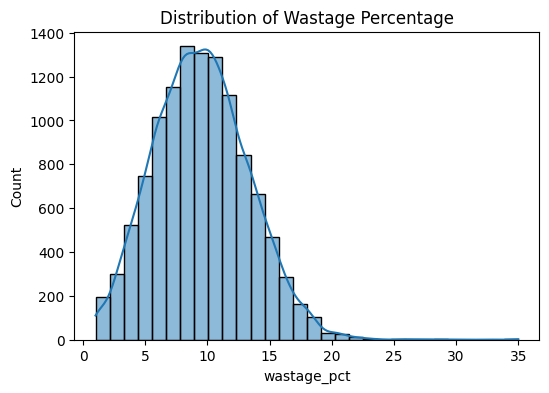

In [14]:
print(df["wastage_pct"].describe())

print()

print(df["wastage_category"].value_counts())

plt.figure(figsize=(6,4))

sns.histplot(
    df["wastage_pct"],
    bins=30,
    kde=True
)

plt.title("Distribution of Wastage Percentage")

plt.show()

# Label Encoding & Model Input Preparation

This section converts categorical variables into numerical values using Label Encoding. These encoders will later be saved and reused by the Streamlit dashboard during inference.

We prepare:

- Regression Target → wastage_pct
- Classification Target → wastage_category
- Feature Matrix → engineered project and material features

In [15]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_columns = [
    "building_type",
    "city",
    "state",
    "sub_category",
    "workforce_skill_level",
    "supervision_quality",
    "project_size"
]

for col in categorical_columns:

    le = LabelEncoder()

    df[col + "_enc"] = le.fit_transform(df[col])

    encoders[col] = le

# Encode target labels
target_encoder = LabelEncoder()

df["wastage_category_enc"] = target_encoder.fit_transform(
    df["wastage_category"]
)

encoders["wastage_category"] = target_encoder

print("Encoding Completed")

Encoding Completed


In [16]:
FEATURES = [

    "building_type_enc",
    "city_enc",
    "state_enc",

    "built_up_area_sqft",
    "num_floors",
    "estimated_duration_months",

    "sub_category_enc",

    "quantity",
    "rate_per_unit_inr",
    "amount_inr",

    "cost_per_quantity",
    "material_cost_ratio",

    "high_value_material",
    "large_quantity",
    "high_rise",

    "workforce_skill_level_enc",
    "supervision_quality_enc",

    "contractor_experience_yrs",

    "logistics_score",

    "month",

    "monsoon_intensity",
    "monsoon_sensitivity"
]

X = df[FEATURES]

y_reg = df["wastage_pct"]

y_clf = df["wastage_category_enc"]

print("Feature Matrix :", X.shape)
print("Regression Target :", y_reg.shape)
print("Classification Target :", y_clf.shape)

Feature Matrix : (11599, 22)
Regression Target : (11599,)
Classification Target : (11599,)


In [17]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print("Regression Train :", X_train_reg.shape)
print("Regression Test  :", X_test_reg.shape)

print()

print("Classification Train :", X_train_clf.shape)
print("Classification Test  :", X_test_clf.shape)

Regression Train : (9279, 22)
Regression Test  : (2320, 22)

Classification Train : (9279, 22)
Classification Test  : (2320, 22)


# Training Wastage Percentage Regressor

The first model predicts the expected material wastage percentage using a LightGBM Regressor.

Evaluation Metrics:
- MAE
- RMSE
- R² Score

In [18]:
reg = lgb.LGBMRegressor(

    n_estimators=400,
    learning_rate=0.04,
    max_depth=7,
    num_leaves=63,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    verbose=-1

)

reg.fit(X_train_reg, y_train_reg)

print("Regression Model Trained Successfully")

Regression Model Trained Successfully


In [19]:
pred_reg = reg.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, pred_reg)

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        pred_reg
    )
)

r2 = r2_score(
    y_test_reg,
    pred_reg
)

print("="*50)

print("MAE :", round(mae,3))

print("="*50)

print("RMSE :", round(rmse,3))

print("="*50)

print("R2 Score :", round(r2,3))

MAE : 1.265
RMSE : 1.58
R2 Score : 0.827


In [20]:
reg_lo = lgb.LGBMRegressor(

    objective="quantile",

    alpha=0.10,

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    random_state=42,

    verbose=-1

)

reg_lo.fit(
    X_train_reg,
    y_train_reg
)

print("Lower Quantile Model Ready")

Lower Quantile Model Ready


In [21]:
reg_hi = lgb.LGBMRegressor(

    objective="quantile",

    alpha=0.90,

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    random_state=42,

    verbose=-1

)

reg_hi.fit(
    X_train_reg,
    y_train_reg
)

print("Upper Quantile Model Ready")

Upper Quantile Model Ready


In [22]:
low = reg_lo.predict(X_test_reg)

high = reg_hi.predict(X_test_reg)

coverage = np.mean(
    (y_test_reg >= low) &
    (y_test_reg <= high)
)

print("Prediction Interval Coverage :", round(coverage*100,2), "%")

Prediction Interval Coverage : 72.33 %


# Training Wastage Category Classifier

This model predicts the wastage category:

- Low
- Medium
- High

using LightGBM Classification.

In [23]:
clf = lgb.LGBMClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    num_leaves=31,

    subsample=0.8,

    random_state=42,

    verbose=-1

)

clf.fit(
    X_train_clf,
    y_train_clf
)

print("Classifier Trained Successfully")

Classifier Trained Successfully


In [24]:
pred_clf = clf.predict(X_test_clf)

labels = encoders["wastage_category"].classes_

print(classification_report(
    y_test_clf,
    pred_clf,
    target_names=labels
))

              precision    recall  f1-score   support

        High       0.73      0.52      0.61       186
         Low       0.70      0.59      0.64       276
      Medium       0.90      0.94      0.92      1858

    accuracy                           0.87      2320
   macro avg       0.78      0.69      0.72      2320
weighted avg       0.86      0.87      0.86      2320



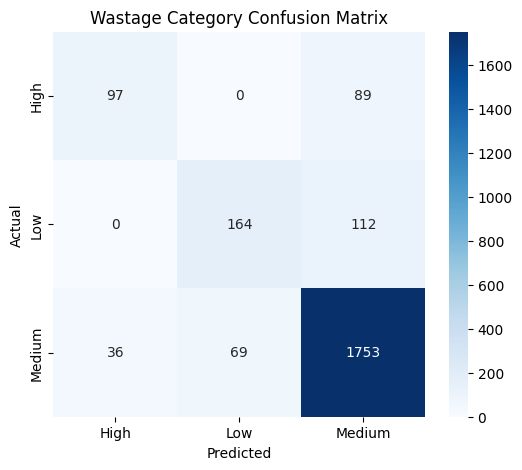

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_clf,
    pred_clf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Wastage Category Confusion Matrix")

plt.show()

In [26]:
# Industry Benchmark Wastage (%)

INDUSTRY_BENCHMARKS = {

    "Concrete": 5,

    "Reinforcement": 4,

    "Masonry": 7,

    "Roofing": 6,

    "Earthwork": 3,

    "Flooring": 5,

    "Finishes": 8,

    "Plaster": 6,

    "Painting": 7,

    "Waterproofing": 5,

    "Doors & Windows": 4,

    "Structural Steel": 5

}

print("Industry Benchmarks Loaded")

Industry Benchmarks Loaded


In [27]:
def benchmark_comparison(material, predicted):

    benchmark = INDUSTRY_BENCHMARKS.get(material, 6)

    difference = predicted - benchmark

    if difference <= 0:

        status = "Within Benchmark"

    else:

        status = "Above Benchmark"

    return {

        "benchmark": benchmark,

        "difference": round(difference,2),

        "status": status

    }

In [28]:
benchmark_comparison(
    "Concrete",
    9.8
)

{'benchmark': 5, 'difference': 4.8, 'status': 'Above Benchmark'}

# SHAP Explainability

This section computes SHAP values to understand which features contribute most to wastage prediction. The resulting feature importance plot will be used in the dashboard and pitch deck.

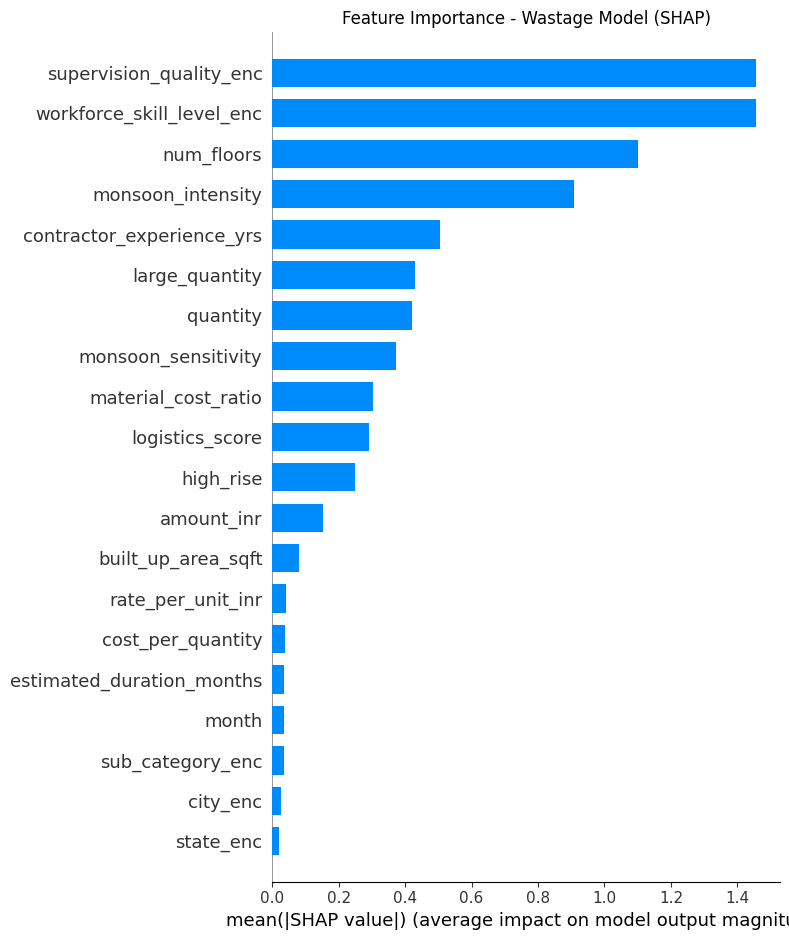

SHAP plot saved as shap_wastage.png


In [29]:
explainer = shap.TreeExplainer(reg)

sample = X_train_reg.sample(
    min(500, len(X_train_reg)),
    random_state=42
)

shap_values = explainer.shap_values(sample)

plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    sample,
    feature_names=FEATURES,
    show=False,
    plot_type="bar"
)

plt.title("Feature Importance - Wastage Model (SHAP)")

plt.tight_layout()

plt.savefig(
    "shap_wastage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP plot saved as shap_wastage.png")

In [30]:
import os
import joblib

# Create models folder
os.makedirs("/kaggle/working/models", exist_ok=True)

# Save models
joblib.dump(reg, "/kaggle/working/models/wastage_regressor.pkl")
joblib.dump(reg_lo, "/kaggle/working/models/wastage_regressor_lo.pkl")
joblib.dump(reg_hi, "/kaggle/working/models/wastage_regressor_hi.pkl")
joblib.dump(clf, "/kaggle/working/models/wastage_classifier.pkl")

# Save encoders
joblib.dump(encoders, "/kaggle/working/models/wastage_encoders.pkl")

# Save feature names
joblib.dump(FEATURES, "/kaggle/working/models/wastage_features.pkl")

print("="*60)
print(" All models saved successfully!")
print("="*60)

print("\nSaved Files:")

for file in os.listdir("/kaggle/working/models"):
    print(file)

 All models saved successfully!

Saved Files:
wastage_regressor.pkl
wastage_regressor_lo.pkl
wastage_features.pkl
wastage_regressor_hi.pkl
wastage_encoders.pkl
wastage_classifier.pkl


In [31]:
import os

os.listdir("/kaggle/working/models")

['wastage_regressor.pkl',
 'wastage_regressor_lo.pkl',
 'wastage_features.pkl',
 'wastage_regressor_hi.pkl',
 'wastage_encoders.pkl',
 'wastage_classifier.pkl']